## 1. Imports & Setup
Imports required libraries: PyTorch for modelling, NumPy and Pandas for data handling, Matplotlib for visualization, and scikit-learn for scaling.

In [1]:
import math
import copy
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
import random

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIG — edit here, run once, then execute the rest of the notebook
# ══════════════════════════════════════════════════════════════════════════════

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 55

# ── Target ────────────────────────────────────────────────────────────────────
# Options: 'price day ahead', 'price actual', 'total load actual',
#          'gen_solar', 'gen_wind'
TARGET = 'price day ahead'

# ── Feature engineering toggles ───────────────────────────────────────────────
ADD_FORECAST   = True   # shift(−24) day-ahead load/solar/wind forecasts
ADD_LAGS       = True   # target lag features
LAG_HOURS      = [1, 2, 3, 24, 48]  # which lags to include when ADD_LAGS=True

# ── Sequence config ───────────────────────────────────────────────────────────
WINDOW_SIZE = 48   # hours of look-back context
HORIZON     = 24   # hours ahead to forecast

# ── Transformer architecture ──────────────────────────────────────────────────
D_MODEL         = 64    # embedding dim — must be divisible by N_HEAD
N_HEAD          = 4
NUM_ENC_LAYERS  = 2
DIM_FEEDFORWARD = 256
DROPOUT         = 0.1

# ── Training ──────────────────────────────────────────────────────────────────
num_epochs    = 50
learning_rate = 1e-4
WEIGHT_DECAY  = 1e-4
GRAD_CLIP     = 1.0     # max_norm for gradient clipping

# ── LR scheduler ─────────────────────────────────────────────────────────────
LR_PATIENCE = 10   # epochs without improvement before halving LR
LR_FACTOR   = 0.5

# ── Loss function ─────────────────────────────────────────────────────────────
# Options: 'mae', 'mse', 'custom'
LOSS_FN     = 'mse'
CUSTOM_ALPHA = 0.1   # weight on JSD term (only used when LOSS_FN='custom')
CUSTOM_BETA  = 0.01  # weight on smoothness term

# ── DataLoader ────────────────────────────────────────────────────────────────
BATCH_SIZE  = 256 if torch.cuda.is_available() else 64
NUM_WORKERS = 4   if torch.cuda.is_available() else 0
PIN_MEMORY  = torch.cuda.is_available()


### Define output path 

In [3]:
import json
from pathlib import Path

output_dir = Path('../../data/non_sequential_model_outputs')
output_dir.mkdir(parents=True, exist_ok=True)

### Manual seed 

In [4]:
# SEED = 55

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print(f"Random seed set to {SEED}")

Random seed set to 55


## 2. Data Loading
Loads the merged energy and weather dataset (35,064 rows x 62 columns) - hourly observations with energy production/consumption and weather features.

In [5]:
energy_weather = pd.read_csv('../../data/processed/energy_weather_merged.csv')
energy_weather.info()
print(f"\nShape: {energy_weather.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 62 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   time                             35064 non-null  object 
 1   date                             35064 non-null  object 
 2   hour                             35064 non-null  int64  
 3   forecast solar day ahead         35064 non-null  float64
 4   forecast wind onshore day ahead  35064 non-null  float64
 5   total load forecast              35064 non-null  float64
 6   total load actual                35064 non-null  float64
 7   price day ahead                  35064 non-null  float64
 8   price actual                     35064 non-null  float64
 9   gen_solar                        35064 non-null  float64
 10  gen_wind                         35064 non-null  float64
 11  gen_hydro                        35064 non-null  float64
 12  gen_pumped_hydro  

## 3. Feature & Target Definition
Set `TARGET` to whichever column you want to predict. Then toggle features on/off by commenting or uncommenting lines in `feature_cols` — the target is automatically excluded. Columns are grouped by category to make it easy to swap between simple and full setups.

In [6]:
# ── Features ─────────────────────────────────────────────────────────────────
# Comment out any column you don't want as an input feature.
# TARGET is automatically removed from this list at the bottom.

feature_cols = [

    # ── Forecasts (day-ahead signals published before the target hour) ────────
    # 'forecast solar day ahead',
    # 'forecast wind onshore day ahead',
    # 'total load forecast',

    # ── Grid & generation ─────────────────────────────────────────────────────
    'total load actual',
    'gen_solar',
    'gen_wind',
    'gen_hydro',
    'gen_pumped_hydro',
    'gen_fossil',
    'gen_nuclear',
    'gen_other',

    # ── Other price series ────────────────────────────────────────────────────
    # 'price actual',

    # ── Weather — temperature (per city) ─────────────────────────────────────
    # 'temp_Barcelona',
    # 'temp_Bilbao',
    # 'temp_Madrid',
    # 'temp_Seville',
    # 'temp_Valencia',
    # 'temp_avg',                   # average across cities — redundant with above

    # ── Weather — wind speed (per city) ──────────────────────────────────────
    # 'wind_speed_Barcelona',
    # 'wind_speed_Bilbao',
    # 'wind_speed_Madrid',
    # 'wind_speed_Seville',
    # 'wind_speed_Valencia',

    # ── Weather — cloud cover (per city) ─────────────────────────────────────
    # 'clouds_all_Barcelona',
    # 'clouds_all_Bilbao',
    # 'clouds_all_Madrid',
    # 'clouds_all_Seville',
    # 'clouds_all_Valencia',

    # ── Weather — rain 3h (per city) ─────────────────────────────────────────
    # 'rain_3h_Barcelona',
    # 'rain_3h_Bilbao',
    # 'rain_3h_Madrid',
    # 'rain_3h_Seville',
    # 'rain_3h_Valencia',

    # ── Weather — rain 1h (per city) — often sparse, consider removing ────────
    # 'rain_1h_Barcelona',
    # 'rain_1h_Bilbao',
    # 'rain_1h_Madrid',
    # 'rain_1h_Seville',
    # 'rain_1h_Valencia',

    # ── Weather — snow 3h (per city) — mostly zero outside winter ────────────
    # 'snow_3h_Barcelona',
    # 'snow_3h_Bilbao',
    # 'snow_3h_Madrid',
    # 'snow_3h_Seville',
    # 'snow_3h_Valencia',

    # ── Weather — wind direction (per city) — circular, consider encoding ─────
    # 'wind_deg_Barcelona',
    # 'wind_deg_Bilbao',
    # 'wind_deg_Madrid',
    # 'wind_deg_Seville',
    # 'wind_deg_Valencia',

    # ── Weather — humidity (per city) ────────────────────────────────────────
    # 'humidity_Barcelona',
    # 'humidity_Bilbao',
    # 'humidity_Madrid',
    # 'humidity_Seville',
    # 'humidity_Valencia',

    # ── Weather — pressure (per city) ────────────────────────────────────────
    # 'pressure_Barcelona',
    # 'pressure_Bilbao',
    # 'pressure_Madrid',
    # 'pressure_Seville',
    # 'pressure_Valencia',
]

# Remove TARGET from features if it appears in the list above
feature_cols = [c for c in feature_cols if c != TARGET]

print(f"Target   : {TARGET}")
print(f"Features ({len(feature_cols)}):")
for col in feature_cols:
    print(f"  {col}")

Target   : price day ahead
Features (8):
  total load actual
  gen_solar
  gen_wind
  gen_hydro
  gen_pumped_hydro
  gen_fossil
  gen_nuclear
  gen_other


## 4. Feature Engineering
Adds cyclical encodings of hour-of-day, day-of-week, and month (sine/cosine pairs) so the model can learn daily and weekly price patterns, plus a binary weekend flag. No lag features are created.

In [7]:
energy_weather['time'] = pd.to_datetime(energy_weather['time'])
energy_weather['year'] = energy_weather['time'].dt.year

# UTC timestamps include one row from 2014-12-31 23:00 UTC
# (= first hour of 2015 in Central European Time). Drop it so
# the year column contains only complete calendar years 2015-2018.
energy_weather = energy_weather[energy_weather['year'] >= 2015].reset_index(drop=True)

hour  = energy_weather['time'].dt.hour
dow   = energy_weather['time'].dt.dayofweek
month = energy_weather['time'].dt.month

energy_weather['hour_sin']   = np.sin(2 * np.pi * hour        / 24)
energy_weather['hour_cos']   = np.cos(2 * np.pi * hour        / 24)
energy_weather['day_sin']    = np.sin(2 * np.pi * dow         / 7)
energy_weather['day_cos']    = np.cos(2 * np.pi * dow         / 7)
energy_weather['month_sin']  = np.sin(2 * np.pi * (month - 1) / 12)
energy_weather['month_cos']  = np.cos(2 * np.pi * (month - 1) / 12)
energy_weather['is_weekend'] = (dow >= 5).astype(float)

time_features = [
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'month_sin', 'month_cos', 'is_weekend',
]
feature_cols = feature_cols + time_features


In [8]:
# ── Forward-looking forecast features (optional) ──────────────────────────────

if ADD_FORECAST:
    energy_weather['total_load_forecast_ahead'] = \
        energy_weather['total load forecast'].shift(-24)
    
    energy_weather['forecast_solar_ahead'] = \
        energy_weather['forecast solar day ahead'].shift(-24)
    
    energy_weather['forecast_wind_ahead'] = \
        energy_weather['forecast wind onshore day ahead'].shift(-24)
    
    forecast_cols = [
        'total_load_forecast_ahead',
        'forecast_solar_ahead',
        'forecast_wind_ahead'
    ]
    feature_cols = feature_cols + forecast_cols
    
    print(f"Forward forecast features added: {forecast_cols}")
    print(f"Total features now: {len(feature_cols)}")
else:
    print("Forward forecast features: disabled")



# ── 3. Lag features ───────────────────────────────────────────────────────────

if ADD_LAGS:
    # lag_hours = [1, 2, 3, 24, 48] (defined in global config)
    lag_cols  = []
    for lag in LAG_HOURS:
        col_name = f"{TARGET.replace(' ', '_')}_lag_{lag}"
        energy_weather[col_name] = energy_weather[TARGET].shift(lag)
        lag_cols.append(col_name)
    feature_cols = feature_cols + lag_cols
    print(f"Lag features added  : {len(lag_cols)}")
    print(f"Total features now  : {len(feature_cols)}")
else:
    lag_cols = []
    print("Lag features: disabled")


Forward forecast features added: ['total_load_forecast_ahead', 'forecast_solar_ahead', 'forecast_wind_ahead']
Total features now: 18
Lag features added  : 5
Total features now  : 23


In [9]:
# ── 4. Single dropna — covers everything ─────────────────────────────────────
energy_weather = energy_weather.dropna(
    subset=feature_cols + [TARGET]
).reset_index(drop=True)

print(f"Shape after feature engineering : {energy_weather.shape}")
print(f"Total input features            : {len(feature_cols)}")
print(f"Years in data                   : {sorted(energy_weather['year'].unique())}")

Shape after feature engineering : (34991, 78)
Total input features            : 23
Years in data                   : [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)]


In [10]:
feature_cols

['total load actual',
 'gen_solar',
 'gen_wind',
 'gen_hydro',
 'gen_pumped_hydro',
 'gen_fossil',
 'gen_nuclear',
 'gen_other',
 'hour_sin',
 'hour_cos',
 'day_sin',
 'day_cos',
 'month_sin',
 'month_cos',
 'is_weekend',
 'total_load_forecast_ahead',
 'forecast_solar_ahead',
 'forecast_wind_ahead',
 'price_day_ahead_lag_1',
 'price_day_ahead_lag_2',
 'price_day_ahead_lag_3',
 'price_day_ahead_lag_24',
 'price_day_ahead_lag_48']

## 5. Train / Validation / Test Split
Splits by calendar year in strict chronological order: **first 2 years -> train, year 3 -> validation, year 4 -> test**. `MinMaxScaler` is fit only on the training set to prevent data leakage. The target has its own scaler so predictions can be inverse-transformed back to EUR/MWh.

In [11]:
years = sorted(energy_weather['year'].unique())

train_df = energy_weather[energy_weather['year'].isin(years[:2])].reset_index(drop=True)
val_df   = energy_weather[energy_weather['year'] == years[2]].reset_index(drop=True)
test_df  = energy_weather[energy_weather['year'] == years[3]].reset_index(drop=True)

# ── Split feature_cols into two groups ───────────────────────────────────────
no_scale_features = time_features                                        # already in [-1, 1]
scale_features    = [c for c in feature_cols if c not in no_scale_features]  # everything else

# Features — fit scaler on train only, applied to scale_features only
feat_scaler = MinMaxScaler()

def scale_features_df(df):
    scaled_part    = feat_scaler.transform(df[scale_features].values)
    noscale_part   = df[no_scale_features].values
    return np.concatenate([scaled_part, noscale_part], axis=1)

feat_scaler.fit(train_df[scale_features].values)

X_train = scale_features_df(train_df)
X_val   = scale_features_df(val_df)
X_test  = scale_features_df(test_df)

# Target — fit on train only
tgt_scaler = MinMaxScaler()
y_train = tgt_scaler.fit_transform(train_df[[TARGET]].values).ravel()
y_val   = tgt_scaler.transform(val_df[[TARGET]].values).ravel()
y_test  = tgt_scaler.transform(test_df[[TARGET]].values).ravel()

print(f"Train : {years[:2]}  ->  {len(train_df):,} rows")
print(f"Val   : {years[2]}   ->  {len(val_df):,} rows")
print(f"Test  : {years[3]}   ->  {len(test_df):,} rows")
print(f"Features scaled    : {len(scale_features)}")
print(f"Features not scaled: {len(no_scale_features)} (sin/cos + is_weekend)")


Train : [np.int32(2015), np.int32(2016)]  ->  17,496 rows
Val   : 2017   ->  8,760 rows
Test  : 2018   ->  8,735 rows
Features scaled    : 16
Features not scaled: 7 (sin/cos + is_weekend)


### Check the distribution of the target variable for skewness/outliers 

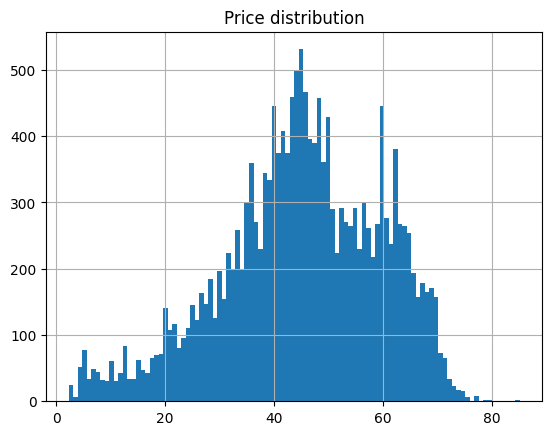

count    17496.000000
mean        45.026782
std         14.658087
min          2.300000
25%         36.100000
50%         45.440000
75%         56.385000
max         85.050000
Name: price day ahead, dtype: float64
Skew: -0.44


In [12]:
import matplotlib.pyplot as plt
train_df[TARGET].hist(bins=100)
plt.title('Price distribution')
plt.show()

print(train_df[TARGET].describe())
print(f"Skew: {train_df[TARGET].skew():.2f}")

## 6. Split Verification
Confirms array shapes and date ranges for each split.

In [13]:
print(f"X_train : {X_train.shape}    y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}      y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}     y_test  : {y_test.shape}")

print(f"\nTrain : {train_df['time'].iloc[0]}  ->  {train_df['time'].iloc[-1]}")
print(f"Val   : {val_df['time'].iloc[0]}  ->  {val_df['time'].iloc[-1]}")
print(f"Test  : {test_df['time'].iloc[0]}  ->  {test_df['time'].iloc[-1]}")

print(f"\nFeature scale check -- X_train : min={X_train.min():.3f}, max={X_train.max():.3f}")
print(f"Target  scale check -- y_train : min={y_train.min():.3f}, max={y_train.max():.3f}")

X_train : (17496, 23)    y_train : (17496,)
X_val   : (8760, 23)      y_val   : (8760,)
X_test  : (8735, 23)     y_test  : (8735,)

Train : 2015-01-03 00:00:00+00:00  ->  2016-12-31 23:00:00+00:00
Val   : 2017-01-01 00:00:00+00:00  ->  2017-12-31 23:00:00+00:00
Test  : 2018-01-01 00:00:00+00:00  ->  2018-12-30 22:00:00+00:00

Feature scale check -- X_train : min=-1.000, max=1.000
Target  scale check -- y_train : min=0.000, max=1.000


## 7. Configuration
Hyperparameters for the data pipeline and Transformer model.

| Parameter | Value | Notes |
|---|---|---|
| `WINDOW_SIZE` | 48 | Hours of look-back the Transformer attends over |
| `HORIZON` | 24 | Hours ahead to forecast |
| `D_MODEL` | 64 | Internal embedding dimension (must be divisible by `N_HEAD`) |
| `N_HEAD` | 4 | Self-attention heads |
| `NUM_ENC_LAYERS` | 2 | Stacked encoder blocks |
| `DIM_FEEDFORWARD` | 256 | FFN hidden dimension inside each encoder block |
| `DROPOUT` | 0.1 | Applied after attention and FFN sub-layers |

In [14]:
INPUT_SIZE      = len(feature_cols)

print(f"Input window     : {WINDOW_SIZE} hours")
print(f"Forecast horizon : {HORIZON} hours")
print(f"Input features   : {INPUT_SIZE}")
print(f"d_model={D_MODEL}, heads={N_HEAD}, enc_layers={NUM_ENC_LAYERS}, ffn={DIM_FEEDFORWARD}")

Input window     : 48 hours
Forecast horizon : 24 hours
Input features   : 23
d_model=64, heads=4, enc_layers=2, ffn=256


## 8. Dataset & DataLoader Construction
`EnergyDataset` slices the data into overlapping windows. For each index the input is the past `WINDOW_SIZE` hours of features and the target is the next `HORIZON` hours of day-ahead price.

In [15]:
class EnergyDataset(Dataset):
    def __init__(self, X, y, window_size=WINDOW_SIZE, horizon=HORIZON):
        self.X           = torch.tensor(X, dtype=torch.float32)
        self.y           = torch.tensor(y, dtype=torch.float32)
        self.window_size = window_size
        self.horizon     = horizon

    def __len__(self):
        return len(self.X) - self.window_size - self.horizon + 1

    def __getitem__(self, idx):
        x_seq = self.X[idx : idx + self.window_size]
        y_seq = self.y[idx + self.window_size : idx + self.window_size + self.horizon]
        return x_seq, y_seq

In [16]:
train_dataset = EnergyDataset(X_train, y_train)
val_dataset   = EnergyDataset(X_val,   y_val)
test_dataset  = EnergyDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

x_sample, y_sample = next(iter(train_loader))
print(f"X batch : {tuple(x_sample.shape)}  ->  expected (batch, {WINDOW_SIZE}, {INPUT_SIZE})")
print(f"y batch : {tuple(y_sample.shape)}  ->  expected (batch, {HORIZON})")

X batch : (256, 48, 23)  ->  expected (batch, 48, 23)
y batch : (256, 24)  ->  expected (batch, 24)


## 9. Model Architecture

A standard Transformer **encoder-only** pipeline:

1. **Input projection** - linear layer maps each timestep from `INPUT_SIZE` raw features to `D_MODEL` dimensions.
2. **Positional encoding** - adds sinusoidal position signals so the model knows the order of timesteps (Transformers have no built-in sense of sequence order).
3. **Transformer encoder** - `NUM_ENC_LAYERS` stacked encoder blocks, each containing:
   - Multi-head self-attention (`N_HEAD` heads, each of size `D_MODEL // N_HEAD`)
   - Feed-forward network (`DIM_FEEDFORWARD` hidden units)
   - Layer norm + residual connections (built into PyTorch's `TransformerEncoderLayer`)
4. **Output head** - takes the **last timestep's** representation and projects it to `HORIZON` output values via a single linear layer.

In [17]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class EnergyTransformer(nn.Module):
    def __init__(self, input_size, d_model=D_MODEL, nhead=N_HEAD,
                 num_encoder_layers=NUM_ENC_LAYERS,
                 dim_feedforward=DIM_FEEDFORWARD,
                 dropout=DROPOUT, horizon=HORIZON):
        super().__init__()
        self.input_proj   = nn.Linear(input_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, dropout)
        encoder_layer     = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True,
        )
        self.transformer  = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)
        self.output_head  = nn.Linear(d_model, horizon)

    def forward(self, x):
        # x: (batch, window_size, input_size)
        x = self.input_proj(x)        # -> (batch, window_size, d_model)
        x = self.pos_encoding(x)      # -> (batch, window_size, d_model)
        x = self.transformer(x)       # -> (batch, window_size, d_model)
        x = x[:, -1, :]              # last timestep -> (batch, d_model)
        return self.output_head(x)    # -> (batch, horizon)

In [18]:
_model = EnergyTransformer(input_size=INPUT_SIZE)
total_params = sum(p.numel() for p in _model.parameters() if p.requires_grad)
print(f"EnergyTransformer -- {total_params:,} trainable parameters")
print(_model)

EnergyTransformer -- 103,064 trainable parameters
EnergyTransformer(
  (input_proj): Linear(in_features=23, out_features=64, bias=True)
  (pos_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_head): Linear(in_features=64, out_features

## 10. Device Selection
Selects the best available compute device: CUDA (NVIDIA GPU) -> MPS (Apple Silicon) -> CPU.

In [19]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA RTX A4000


## 11. Training & Evaluation Functions
`train_model()` uses **MSE loss** for training (smoother gradients than MAE), an Adam optimizer, and a `ReduceLROnPlateau` scheduler that halves the learning rate after 5 epochs without improvement. `test_model()` evaluates on the test set and inverse-transforms predictions back to original price units (EUR/MWh), reporting **MAE** and **RMSE** as the final metrics.

### Custom Loss Function 

In [20]:
import copy

# ── Custom Loss ───────────────────────────────────────────────────────────────
class CustomLoss(nn.Module):
    def __init__(self, alpha=0.1, beta=0.01):
        super(CustomLoss, self).__init__()
        self.alpha = alpha
        self.beta  = beta

    def forward(self, y_pred, y_true):
        y_pred = y_pred.squeeze()
        y_true = y_true.squeeze()

        # ── MAE ──────────────────────────────────────────
        mae = torch.mean(torch.abs(y_true - y_pred))

        # ── JSD ──────────────────────────────────────────
        y_true_soft = torch.softmax(y_true, dim=0)
        y_pred_soft = torch.softmax(y_pred, dim=0)
        m           = 0.5 * (y_true_soft + y_pred_soft)
        kl1         = torch.sum(
            y_true_soft * torch.log(y_true_soft / (m + 1e-8) + 1e-8))
        kl2         = torch.sum(
            y_pred_soft * torch.log(y_pred_soft / (m + 1e-8) + 1e-8))
        jsd         = 0.5 * (kl1 + kl2)

        # ── Smoothness ────────────────────────────────────
        smoothness = torch.mean((y_pred[1:] - y_pred[:-1]) ** 2)

        return mae + self.alpha * jsd + self.beta * smoothness

### Training loop 

In [21]:
def train_model(model, train_loader, val_loader,
                num_epochs=50, lr=1e-3, device='cpu',
                print_every=1, loss_fn='mae',
                weight_decay=1e-4, alpha=0.1, beta=0.01):

    model     = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=10, factor=0.5
    )

    # ── Loss selection ────────────────────────────────────────────────────────
    if loss_fn == 'mae':
        criterion  = nn.L1Loss()
        loss_label = 'MAE'
    elif loss_fn == 'mse':
        criterion  = nn.MSELoss()
        loss_label = 'MSE'
    elif loss_fn == 'custom':
        criterion  = CustomLoss(alpha=alpha, beta=beta)
        loss_label = f'Custom (α={alpha} β={beta})'
    else:
        raise ValueError(f"loss_fn must be 'mae', 'mse' or 'custom', got '{loss_fn}'")

    print(f"Training with {loss_label} loss")

    best_val_loss = float('inf')
    best_weights  = copy.deepcopy(model.state_dict())
    history       = {'train_loss': [], 'val_loss': [], 'lr': []}

    for epoch in range(num_epochs):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_losses.append(criterion(model(X_batch), y_batch).item())

        train_loss = float(np.mean(train_losses))
        val_loss   = float(np.mean(val_losses))
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = copy.deepcopy(model.state_dict())

        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1:3d}/{num_epochs}  "
                  f"train={train_loss:.4f}  val={val_loss:.4f}  "
                  f"lr={optimizer.param_groups[0]['lr']:.2e}")

    model.load_state_dict(best_weights)
    print(f"\nBest val loss ({loss_label}): {best_val_loss:.4f}")
    return model, history


## 12. Training Execution
Trains the Transformer on the 2-year training set, monitors on the validation year, then evaluates on the held-out test year.

In [22]:
import time

assert X_train.shape[1] == INPUT_SIZE, (
    f"Feature mismatch: X_train has {X_train.shape[1]} features but "
    f"INPUT_SIZE={INPUT_SIZE}. Re-run cells 6 → 8 → 13 → 17 before training."
)

model = EnergyTransformer(input_size=INPUT_SIZE).to(device)

t0 = time.time()
trained_model, history = train_model(
    model, train_loader, val_loader,
    num_epochs=num_epochs, lr=learning_rate, device=device, loss_fn=LOSS_FN, weight_decay=WEIGHT_DECAY
)

elapsed = time.time() - t0

mins, secs = divmod(int(elapsed), 60)
print(f"\nTotal training time: {mins}m {secs}s")

Training with MSE loss
Epoch   1/50  train=0.1700  val=0.0320  lr=1.00e-04
Epoch   2/50  train=0.0494  val=0.0281  lr=1.00e-04
Epoch   3/50  train=0.0421  val=0.0256  lr=1.00e-04
Epoch   4/50  train=0.0378  val=0.0233  lr=1.00e-04
Epoch   5/50  train=0.0330  val=0.0207  lr=1.00e-04
Epoch   6/50  train=0.0291  val=0.0177  lr=1.00e-04
Epoch   7/50  train=0.0256  val=0.0155  lr=1.00e-04
Epoch   8/50  train=0.0236  val=0.0150  lr=1.00e-04
Epoch   9/50  train=0.0223  val=0.0146  lr=1.00e-04
Epoch  10/50  train=0.0210  val=0.0146  lr=1.00e-04
Epoch  11/50  train=0.0199  val=0.0141  lr=1.00e-04
Epoch  12/50  train=0.0190  val=0.0138  lr=1.00e-04
Epoch  13/50  train=0.0181  val=0.0135  lr=1.00e-04
Epoch  14/50  train=0.0174  val=0.0134  lr=1.00e-04
Epoch  15/50  train=0.0165  val=0.0131  lr=1.00e-04
Epoch  16/50  train=0.0159  val=0.0129  lr=1.00e-04
Epoch  17/50  train=0.0154  val=0.0126  lr=1.00e-04
Epoch  18/50  train=0.0148  val=0.0123  lr=1.00e-04
Epoch  19/50  train=0.0142  val=0.0122  l

## 13. Testing & Evaluation 

### Helper functions for testing/evaluation 

In [23]:
def compute_metrics(preds_orig, actuals_orig):
    mae  = float(np.mean(np.abs(preds_orig - actuals_orig)))
    rmse = float(np.sqrt(np.mean((preds_orig - actuals_orig) ** 2)))
    mape = float(np.mean(np.abs((actuals_orig - preds_orig) /
                                 np.abs(actuals_orig).clip(min=1.0))) * 100)
    mae_per_horizon = np.mean(np.abs(preds_orig - actuals_orig), axis=0)
    return mae, rmse, mape, mae_per_horizon


def print_metrics(mae, rmse, mape, mae_per_horizon):
    print(f"MAE  : {mae:.3f} EUR/MWh  (on average, predictions are off by {mae:.1f} EUR/MWh)")
    print(f"RMSE : {rmse:.3f} EUR/MWh  (higher than MAE means occasional big misses)")
    print(f"MAPE : {mape:.2f}%          (on average, predictions are off by {mape:.1f}% of the actual price)")
    # print(f"\nPer-horizon MAE (EUR/MWh)  — does error grow the further ahead we predict?")
    # for h, m in enumerate(mae_per_horizon, 1):
    #     bar = '█' * int(m)
    #     print(f"  h+{h:02d} : {m:6.3f}  {bar}")

### Non-overlapping version 

In [24]:
def forecast_production(model, X_test, y_test, tgt_scaler, device='cpu',
                        window_size=WINDOW_SIZE, horizon=HORIZON):
    model.eval()
    X_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_tensor = torch.tensor(y_test, dtype=torch.float32)
    preds, actuals = [], []

    with torch.no_grad():
        for start in range(0, len(X_test) - window_size - horizon + 1, horizon):
            x_window = X_tensor[start : start + window_size].unsqueeze(0).to(device)
            y_window = y_tensor[start + window_size : start + window_size + horizon].numpy()
            pred     = model(x_window).cpu().numpy()
            preds.append(pred)
            actuals.append(y_window)

    preds   = np.concatenate(preds,  axis=0)   # (N_days, 24)
    actuals = np.stack(actuals,      axis=0)   # (N_days, 24)

    preds_orig   = tgt_scaler.inverse_transform(preds.reshape(-1, 1)).reshape(preds.shape)
    actuals_orig = tgt_scaler.inverse_transform(actuals.reshape(-1, 1)).reshape(actuals.shape)

    mae, rmse, mape, mae_per_horizon = compute_metrics(preds_orig, actuals_orig)

    print(f"── Production Forecast Metrics (non-overlapping, stride={horizon}) ──")
    print(f"Windows : {len(preds)} day-ahead forecasts")
    print_metrics(mae, rmse, mape, mae_per_horizon)

    return {
        'preds'           : preds_orig,        # (N_days, 24) — consistent with test_model
        'actuals'         : actuals_orig,      # (N_days, 24)
        'mae'             : mae,
        'rmse'            : rmse,
        'mape'            : mape,
        'mae_per_horizon' : mae_per_horizon,
        'n_windows'       : len(preds),
    }

In [25]:
print("\n── Non-Overlapping Version (Production Simulation) ──")
prod = forecast_production(trained_model, X_test, y_test, tgt_scaler, device=device)


── Non-Overlapping Version (Production Simulation) ──
── Production Forecast Metrics (non-overlapping, stride=24) ──
Windows : 361 day-ahead forecasts
MAE  : 6.492 EUR/MWh  (on average, predictions are off by 6.5 EUR/MWh)
RMSE : 8.209 EUR/MWh  (higher than MAE means occasional big misses)
MAPE : 15.53%          (on average, predictions are off by 15.5% of the actual price)


── Production Forecast Metrics (non-overlapping, stride=24) ──
Windows : 361 day-ahead forecasts
MAE  : 5.778 EUR/MWh  (on average, predictions are off by 5.8 EUR/MWh)
RMSE : 7.339 EUR/MWh  (higher than MAE means occasional big misses)
MAPE : 13.52%          (on average, predictions are off by 13.5% of the actual price)


## 13. Visualization 
Four plots: the first 30 days of the test period (unrolled predictions), a sample 24-hour forecast horizon, the residual distribution, and training/validation loss curves.

In [26]:
def plot_results(results, history, plot_days=30):
    preds   = results['preds']
    actuals = results['actuals']

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Day-Ahead Price Forecast -- Transformer', fontsize=14, fontweight='bold')

    # First N days of test period (sequences unrolled)
    ax        = axes[0, 0]
    n_hours   = plot_days * 24
    n         = min(n_hours, len(preds.ravel()))
    actual_days = n // 24  # how many complete days are actually shown
    ax.plot(actuals.ravel()[:n], label='Actual',    alpha=0.8, linewidth=0.8)
    ax.plot(preds.ravel()[:n],   label='Predicted', alpha=0.8, linewidth=0.8)
    ax.set_title(f'First {actual_days} days of test period')
    ax.set_xlabel('Hour')
    ax.set_ylabel('Price (EUR/MWh)')
    ax.legend()

    # Sample 24h forecast horizon
    ax  = axes[0, 1]
    idx = 200
    ax.plot(range(HORIZON), actuals[idx], marker='o', label='Actual',    linewidth=1.5)
    ax.plot(range(HORIZON), preds[idx],   marker='x', label='Predicted', linewidth=1.5)
    ax.set_title(f'Sample 24 h horizon (sequence #{idx})')
    ax.set_xlabel('Hour ahead')
    ax.set_ylabel('Price (EUR/MWh)')
    ax.legend()

    # Residual distribution
    ax     = axes[1, 0]
    errors = (preds - actuals).ravel()
    ax.hist(errors, bins=60, edgecolor='black', linewidth=0.4)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.2,
            label=f'Zero error (perfect)')
    ax.axvline(results['mae'], color='orange', linestyle='--', linewidth=1.2,
            label=f'MAE = ±{results["mae"]:.2f} EUR/MWh')
    ax.axvline(-results['mae'], color='orange', linestyle='--', linewidth=1.2)
    ax.set_title('Residual distribution')
    ax.set_xlabel('Error (EUR/MWh)')
    ax.set_ylabel('Count')
    ax.legend()

    # ── Bottom right: Training history ───────────────────────────────────────
    ax = axes[1, 1]
    ax.plot(history['train_loss'], label=f'Train ({LOSS_FN.upper()})')
    ax.plot(history['val_loss'],   label=f'Val ({LOSS_FN.upper()})')
    ax.set_title(f'Training history  |  loss={LOSS_FN.upper()}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(f'{LOSS_FN.upper()} loss (scaled)')
    ax.legend()

    plt.tight_layout()
    plt.show()

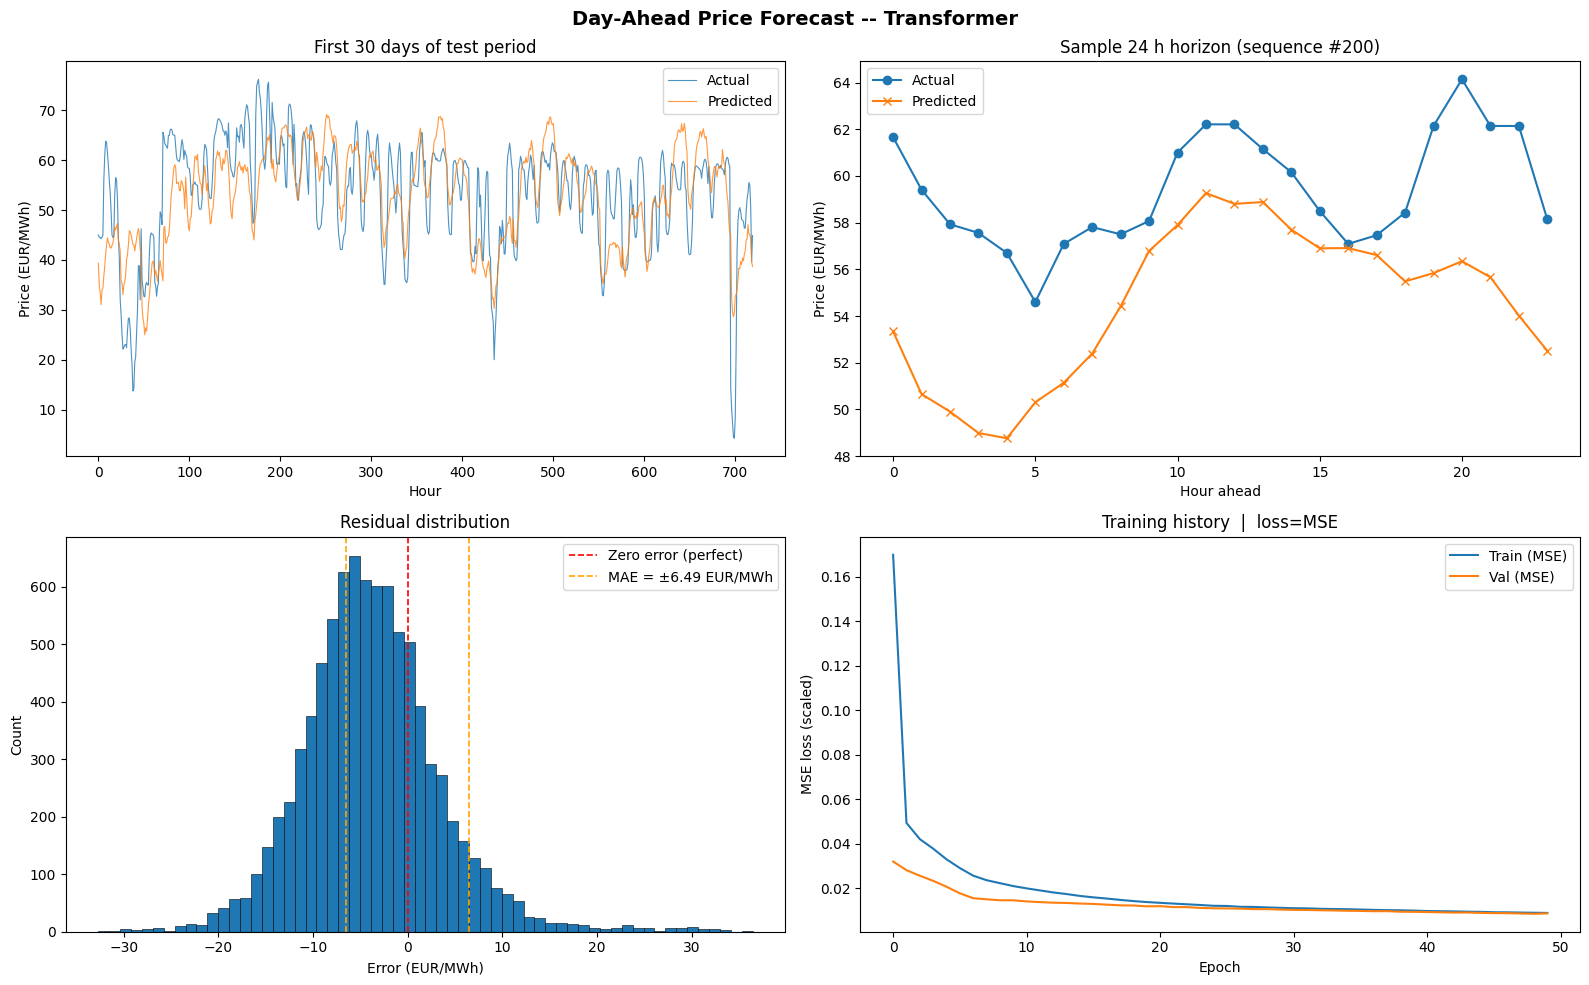

In [27]:
plot_results(prod, history, plot_days=30)

### Main Outputs 

In [28]:
mins, secs = divmod(int(elapsed), 60)
if device.type == 'cuda':
    device_label = f"cuda ({torch.cuda.get_device_name(0)})"
elif device.type == 'mps':
    device_label = "mps (Apple Silicon)"
else:
    device_label = "cpu"

print(f"\nTotal training time: {mins}m {secs}s  |  device: {device_label}")


Total training time: 1m 48s  |  device: cuda (NVIDIA RTX A4000)


In [29]:
results = prod.copy()

print(f"MAE  : {results['mae']:.3f} EUR/MWh  (on average, predictions are off by {results['mae']:.1f} EUR/MWh)")
print(f"RMSE : {results['rmse']:.3f} EUR/MWh  (higher than MAE means occasional big misses)")
print(f"MAPE : {results['mape']:.2f}%          (on average, predictions are off by {results['mape']:.1f}% of the actual price)")

MAE  : 6.492 EUR/MWh  (on average, predictions are off by 6.5 EUR/MWh)
RMSE : 8.209 EUR/MWh  (higher than MAE means occasional big misses)
MAPE : 15.53%          (on average, predictions are off by 15.5% of the actual price)


### Results by season 

In [30]:
def evaluate_by_season(results, test_df, stride=1):
    preds   = results['preds']
    actuals = results['actuals']
    n       = len(preds)

    times = pd.to_datetime(test_df['time'].values)

    # generate start indices based on stride
    starts = list(range(WINDOW_SIZE,
                        WINDOW_SIZE + n * stride,
                        stride))[:n]
    times  = times[starts]

    month  = pd.Series(times).dt.month

    seasons = {
        'Winter' : month.isin([12, 1, 2]),
        'Spring' : month.isin([3, 4, 5]),
        'Summer' : month.isin([6, 7, 8]),
        'Autumn' : month.isin([9, 10, 11]),
    }

    print(f"\n── Seasonal Error Breakdown (stride={stride}) ───────────────")
    print(f"{'Season':<10} {'N':>6} {'MAE':>8} {'RMSE':>8} {'MAPE':>8}")
    print(f"{'─'*44}")

    season_results = {}
    for season, mask in seasons.items():
        s_preds   = preds[mask.values].ravel()
        s_actuals = actuals[mask.values].ravel()

        mae  = float(np.mean(np.abs(s_preds - s_actuals)))
        rmse = float(np.sqrt(np.mean((s_preds - s_actuals) ** 2)))
        mape = float(np.mean(np.abs((s_actuals - s_preds) /
                                     np.abs(s_actuals).clip(min=1.0))) * 100)

        print(f"{season:<10} {mask.sum():>6,} {mae:>8.3f} {rmse:>8.3f} {mape:>7.2f}%")

        season_results[season] = {
            'mae' : mae,
            'rmse': rmse,
            'mape': mape,
            'n'   : int(mask.sum())
        }

    print(f"{'─'*44}")
    print(f"{'Overall':<10} {n:>6,} "
          f"{results['mae']:>8.3f} "
          f"{results['rmse']:>8.3f} "
          f"{results['mape']:>7.2f}%")

    return season_results

In [31]:
# overlapping
season_results = evaluate_by_season(prod, test_df, stride=24)


── Seasonal Error Breakdown (stride=24) ───────────────
Season          N      MAE     RMSE     MAPE
────────────────────────────────────────────
Winter         86    6.028    7.837   13.05%
Spring         92    7.023    8.856   22.80%
Summer         92    5.971    7.363   10.32%
Autumn         91    6.919    8.673   15.78%
────────────────────────────────────────────
Overall       361    6.492    8.209   15.53%


In [32]:
## save to file 

In [33]:
# in the DA notebook:
with open(output_dir / 'da_season_results.json', 'w') as f:
    json.dump(season_results, f, indent=2)

In [34]:
def plot_seasonal(season_results):
    seasons = list(season_results.keys())
    maes    = [season_results[s]['mae']  for s in seasons]
    rmses   = [season_results[s]['rmse'] for s in seasons]
    mapes   = [season_results[s]['mape'] for s in seasons]

    x = np.arange(len(seasons))
    width = 0.25

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Forecast Error by Season — 2018 Test Set',
                 fontsize=13, fontweight='bold')

    for ax, values, label, color in zip(
        axes,
        [maes, rmses, mapes],
        ['MAE (EUR/MWh)', 'RMSE (EUR/MWh)', 'MAPE (%)'],
        ['steelblue', 'darkorange', 'seagreen']
    ):
        bars = ax.bar(x, values, color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(seasons)
        ax.set_ylabel(label)
        ax.set_title(label)
        ax.grid(axis='y', alpha=0.3)

        # value labels on bars
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.05,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

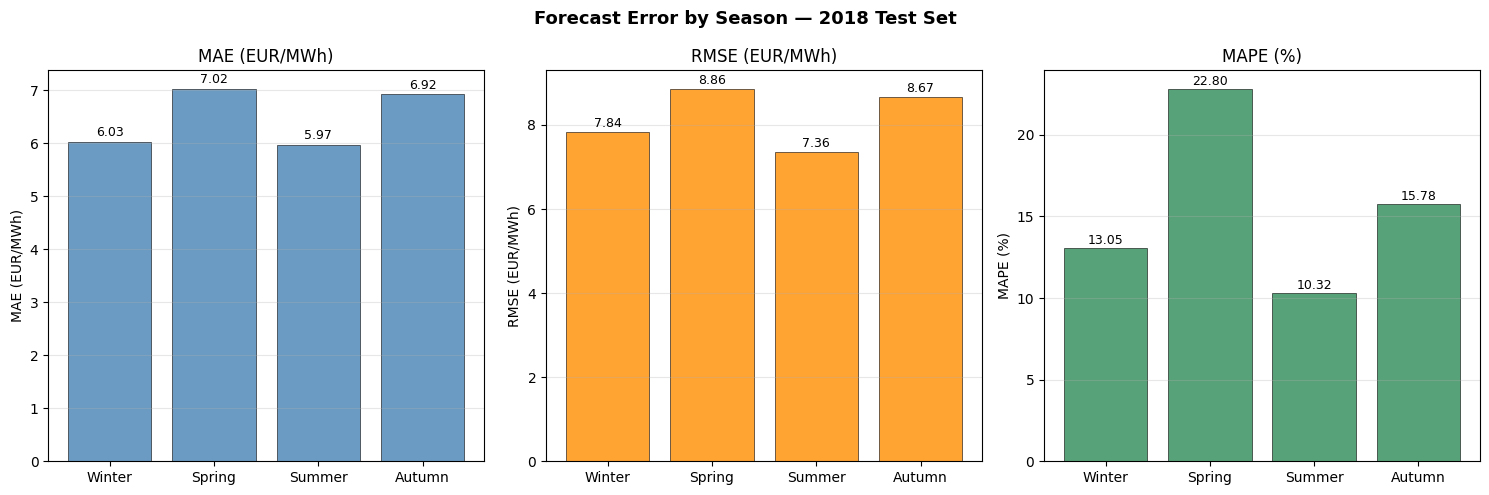

In [35]:
plot_seasonal(season_results)

### Plot RT & DA side by side  

#### read `RT` json from file 

In [36]:
with open(output_dir / 'rt_season_results.json') as f:
    rt_season_results = json.load(f)

In [37]:
rt_season_results

{'Winter': {'mae': 2.7786145210266113,
  'rmse': 3.736409902572632,
  'mape': 5.008435249328613,
  'n': 2134},
 'Spring': {'mae': 3.149064540863037,
  'rmse': 4.166684150695801,
  'mape': 7.209309101104736,
  'n': 2208},
 'Summer': {'mae': 2.2369742393493652,
  'rmse': 2.8316493034362793,
  'mape': 3.337599992752075,
  'n': 2208},
 'Autumn': {'mae': 3.0117743015289307,
  'rmse': 3.802138090133667,
  'mape': 4.283498287200928,
  'n': 2184}}

In [38]:
da_season_results = season_results.copy()

In [39]:
import matplotlib.ticker as mticker

def plot_seasonal_comparison(
    da_results,
    rt_results,
    figsize=(14, 5),
    xlabel_size=12,
    ylabel_size=15,
    xlabel_weight='normal',
    ylabel_weight='normal',
    tick_weight='normal',
    annotate=False,
    legend_loc='upper right',
    legend_bbox=None,
    legend_fontsize=10,
    shared_ylim=True,
    save_path=None,
    dpi=300,
):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    titles    = ['Day-Ahead', 'Real-Time']

    if shared_ylim:
        all_maes  = [v['mae']  for r in [da_results, rt_results] for v in r.values()]
        all_mapes = [v['mape'] for r in [da_results, rt_results] for v in r.values()]
        mae_ylim  = (0, max(all_maes)  * 1.15)
        mape_ylim = (0, max(all_mapes) * 1.15)

    for ax1, results, title in zip(axes, [da_results, rt_results], titles):
        seasons = list(results.keys())
        maes    = [results[s]['mae']  for s in seasons]
        mapes   = [results[s]['mape'] for s in seasons]

        x     = np.arange(len(seasons))
        width = 0.35
        ax2   = ax1.twinx()

        bars1 = ax1.bar(x - width/2, maes,  width, color='steelblue', alpha=0.8,
                        edgecolor='black', linewidth=0.5, label='MAE')
        bars2 = ax2.bar(x + width/2, mapes, width, color='seagreen',  alpha=0.8,
                        edgecolor='black', linewidth=0.5, label='MAPE')

        ax1.set_xticks(x)
        ax1.set_xticklabels(seasons, fontsize=xlabel_size, fontweight=xlabel_weight)
        ax1.set_ylabel('MAE (EUR/MWh)', fontsize=ylabel_size, fontweight=ylabel_weight,
                       color='steelblue', labelpad=10)
        ax2.set_ylabel('MAPE (%)',       fontsize=ylabel_size, fontweight=ylabel_weight,
                       color='seagreen',  labelpad=10)
        ax1.set_title(title, fontsize=13, fontweight='bold')

        ax2.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))

        if shared_ylim:
            ax1.set_ylim(mae_ylim)
            ax2.set_ylim(mape_ylim)

        for ax in (ax1, ax2):
            ax.tick_params(axis='y', labelsize=xlabel_size)
            for tick in ax.get_yticklabels():
                tick.set_fontweight(tick_weight)
            ax.spines['top'].set_visible(False)

        for spine in (ax1.spines['left'], ax2.spines['left']):
            spine.set_color('steelblue')
            spine.set_linewidth(1.5)
        ax2.spines['right'].set_color('seagreen')
        ax2.spines['right'].set_linewidth(1.5)

        ax1.tick_params(axis='y', colors='steelblue')
        ax2.tick_params(axis='y', colors='seagreen')

        if annotate:
            for bar, val in zip(bars1, maes):
                ax1.text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + 0.05,
                         f'{val:.2f}', ha='center', va='bottom', fontsize=9, color='steelblue')
            for bar, val in zip(bars2, mapes):
                ax2.text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + 0.05,
                         f'{val:.2f}%', ha='center', va='bottom', fontsize=9, color='seagreen')

        ax1.grid(axis='y', alpha=0.3)

    legend_kwargs = dict(fontsize=legend_fontsize, loc=legend_loc)
    if legend_bbox is not None:
        legend_kwargs['bbox_to_anchor'] = legend_bbox
    axes[-1].legend([bars1, bars2], ['MAE (EUR/MWh)', 'MAPE (%)'], **legend_kwargs)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()

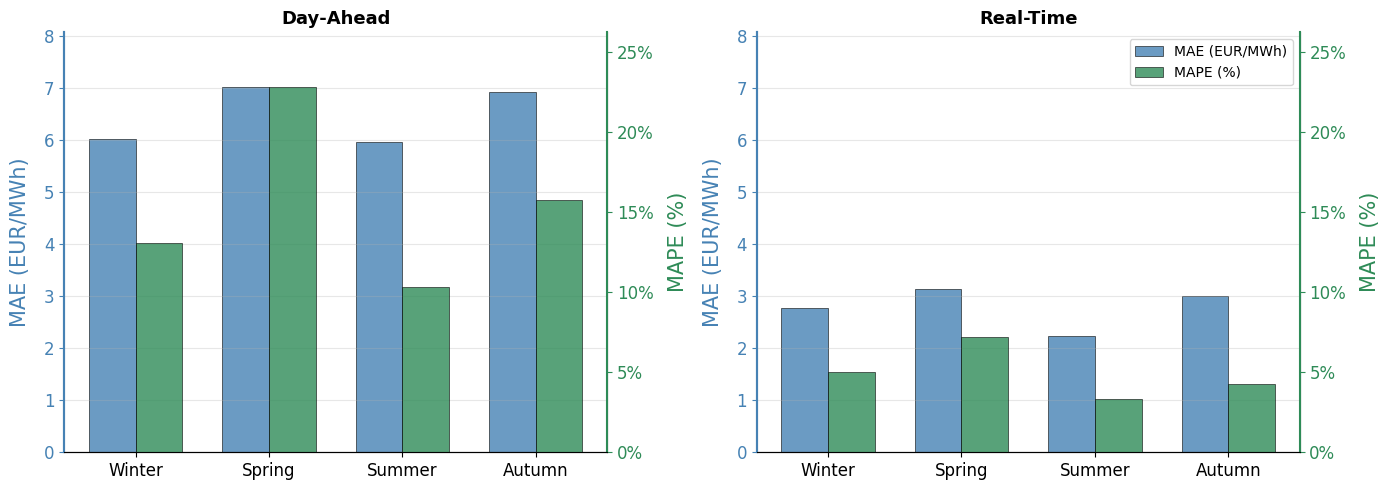

In [40]:
plot_seasonal_comparison(da_season_results, rt_season_results)

In [41]:
def plot_seasonal_comparison(
    da_results,
    rt_results,
    figsize=(14, 5),
    xlabel_size=12,
    ylabel_size=15,
    xlabel_weight='normal',
    ylabel_weight='bold',
    tick_weight='normal',
    annotate=False,
    legend_loc='upper right',
    legend_bbox=None,
    legend_fontsize=11,
    shared_ylim=True,
    save_path=None,
    dpi=300,
):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    titles    = ['Day-Ahead', 'Real-Time']

    if shared_ylim:
        all_maes  = [v['mae']  for r in [da_results, rt_results] for v in r.values()]
        all_mapes = [v['mape'] for r in [da_results, rt_results] for v in r.values()]
        mae_ylim  = (0, max(all_maes)  * 1.15)
        mape_ylim = (0, max(all_mapes) * 1.15)

    for i, (ax1, results, title) in enumerate(zip(axes, [da_results, rt_results], titles)):
        seasons = list(results.keys())
        maes    = [results[s]['mae']  for s in seasons]
        mapes   = [results[s]['mape'] for s in seasons]

        x     = np.arange(len(seasons))
        width = 0.35
        ax2   = ax1.twinx()

        bars1 = ax1.bar(x - width/2, maes,  width, color='steelblue', alpha=0.8,
                        edgecolor='black', linewidth=0.5, label='MAE')
        bars2 = ax2.bar(x + width/2, mapes, width, color='seagreen',  alpha=0.8,
                        edgecolor='black', linewidth=0.5, label='MAPE')

        ax1.set_xticks(x)
        ax1.set_xticklabels(seasons, fontsize=xlabel_size, fontweight=xlabel_weight)
        ax1.set_title(title, fontsize=13, fontweight='bold')

        ax2.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))

        if shared_ylim:
            ax1.set_ylim(mae_ylim)
            ax2.set_ylim(mape_ylim)

        # left panel: keep left (MAE), hide right (MAPE)
        # right panel: hide left (MAE), keep right (MAPE)
        if i == 0:
            ax1.set_ylabel('MAE (EUR/MWh)', fontsize=ylabel_size, fontweight=ylabel_weight,
                           color='steelblue', labelpad=10)
            ax2.set_ylabel('')
            ax2.tick_params(axis='y', left=False, right=False, labelright=False)
            # ax2.tick_params(axis='y', labelright=False)
            ax2.spines['right'].set_visible(False)
        else:
            ax2.set_ylabel('MAPE (%)', fontsize=ylabel_size, fontweight=ylabel_weight,
                           color='seagreen', labelpad=10)
            ax1.set_ylabel('')
            ax1.tick_params(axis='y', left=False, right=False, labelleft=False)
            # ax1.tick_params(axis='y', labelleft=False)
            ax1.spines['left'].set_visible(False)

        for ax in (ax1, ax2):
            ax.spines['top'].set_visible(False)
            ax.tick_params(axis='y', labelsize=xlabel_size)
            for tick in ax.get_yticklabels():
                tick.set_fontweight(tick_weight)

        # colour the visible spines and ticks
        if i == 0:
            for spine in (ax1.spines['left'], ax2.spines['left']):
                spine.set_color('steelblue')
                spine.set_linewidth(1.5)
            ax1.tick_params(axis='y', colors='steelblue')
        else:
            ax2.spines['right'].set_color('seagreen')
            ax2.spines['right'].set_linewidth(1.5)
            ax2.spines['left'].set_color('steelblue')
            ax2.tick_params(axis='y', colors='seagreen')

        if annotate:
            for bar, val in zip(bars1, maes):
                ax1.text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + 0.05,
                         f'{val:.2f}', ha='center', va='bottom', fontsize=9, color='steelblue')
            for bar, val in zip(bars2, mapes):
                ax2.text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + 0.05,
                         f'{val:.2f}%', ha='center', va='bottom', fontsize=9, color='seagreen')

        ax1.grid(axis='y', alpha=0.3)

    legend_kwargs = dict(fontsize=legend_fontsize, loc=legend_loc)
    if legend_bbox is not None:
        legend_kwargs['bbox_to_anchor'] = legend_bbox
    axes[-1].legend([bars1, bars2], ['MAE (EUR/MWh)', 'MAPE (%)'], **legend_kwargs)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()

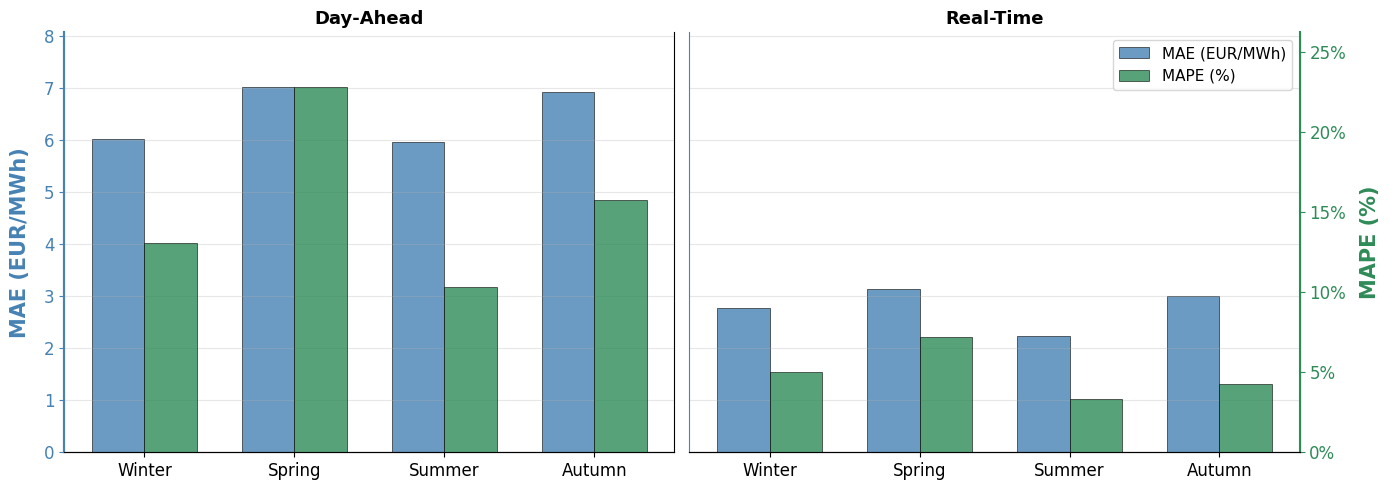

In [42]:
plot_seasonal_comparison(da_season_results, rt_season_results)

### Additional Seasonal Error plots 

In [97]:
def plot_seasonal_comparison(
    da_results,
    rt_results,
    figsize=(7, 9),
    xlabel_size=12,
    ylabel_size=15,
    xlabel_weight='normal',
    ylabel_weight='bold',
    tick_weight='normal',
    annotate=False,
    legend_loc='upper right',
    legend_bbox=None,
    legend_fontsize=11.5,
    shared_ylim=True,
    color_mae='steelblue',
    color_mape='seagreen',
    hide_top_xticks=True,
    save_path=None,
    dpi=300,
):
    fig, axes = plt.subplots(2, 1, figsize=figsize)
    titles    = ['Day-Ahead Price', 'Real-Time Price']

    if shared_ylim:
        all_maes  = [v['mae']  for r in [da_results, rt_results] for v in r.values()]
        all_mapes = [v['mape'] for r in [da_results, rt_results] for v in r.values()]
        mae_ylim  = (0, max(all_maes)  * 1.15)
        mape_ylim = (0, max(all_mapes) * 1.15)

    twin_axes = []

    for ax1, results, title in zip(axes, [da_results, rt_results], titles):
        seasons = list(results.keys())
        maes    = [results[s]['mae']  for s in seasons]
        mapes   = [results[s]['mape'] for s in seasons]

        x     = np.arange(len(seasons))
        width = 0.35
        ax2   = ax1.twinx()
        twin_axes.append(ax2)

        bars1 = ax1.bar(x - width/2, maes,  width, color=color_mae,  alpha=0.8,
                        edgecolor='black', linewidth=0.5, label='MAE')
        bars2 = ax2.bar(x + width/2, mapes, width, color=color_mape, alpha=0.8,
                        edgecolor='black', linewidth=0.5, label='MAPE')

        ax1.set_xticks(x)
        ax1.set_xticklabels(seasons, fontsize=xlabel_size, fontweight=xlabel_weight)
        ax1.set_title(title, fontsize=13, fontweight='normal')

        ax2.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))

        if shared_ylim:
            ax1.set_ylim(mae_ylim)
            ax2.set_ylim(mape_ylim)

        ax1.set_ylabel('')
        ax2.set_ylabel('')

        for ax in (ax1, ax2):
            ax.spines['top'].set_visible(False)
            ax.tick_params(axis='y', labelsize=xlabel_size)
            for tick in ax.get_yticklabels():
                tick.set_fontweight(tick_weight)

        ax2.spines['left'].set_visible(False)

        ax1.spines['left'].set_color(color_mae)
        ax1.spines['left'].set_linewidth(1.5)
        ax1.tick_params(axis='y', colors=color_mae)

        ax2.spines['right'].set_color(color_mape)
        ax2.spines['right'].set_linewidth(1.5)
        ax2.tick_params(axis='y', colors=color_mape)

        if annotate:
            for bar, val in zip(bars1, maes):
                ax1.text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + 0.05,
                         f'{val:.2f}', ha='center', va='bottom', fontsize=9, color=color_mae)
            for bar, val in zip(bars2, mapes):
                ax2.text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + 0.05,
                         f'{val:.2f}%', ha='center', va='bottom', fontsize=9, color=color_mape)

        ax1.grid(axis='y', alpha=0.3)

    if hide_top_xticks:
        axes[0].tick_params(axis='x', labelbottom=False)
        # axes[0].spines['bottom'].set_visible(False)
        # twin_axes[0].spines['bottom'].set_visible(False)

    # legend_kwargs = dict(fontsize=legend_fontsize, loc=legend_loc)
    # if legend_bbox is not None:
    #     legend_kwargs['bbox_to_anchor'] = legend_bbox
    # axes[-1].legend([bars1, bars2], ['MAE (EUR/MWh)', 'MAPE (%)'], **legend_kwargs)

    legend_kwargs = dict(fontsize=legend_fontsize, loc=legend_loc)
    if legend_bbox is not None:
        legend_kwargs['bbox_to_anchor'] = legend_bbox
    fig.legend([bars1, bars2], ['MAE (EUR/MWh)', 'MAPE (%)'], **legend_kwargs)


    plt.tight_layout()

    fig.text(-0.03, 0.5, 'MAE (EUR/MWh)', fontsize=ylabel_size, fontweight=ylabel_weight,
             color=color_mae, ha='center', va='center', rotation='vertical')
    fig.text(1.02, 0.5, 'MAPE (%)', fontsize=ylabel_size, fontweight=ylabel_weight,
             color=color_mape, ha='center', va='center', rotation='vertical')

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()

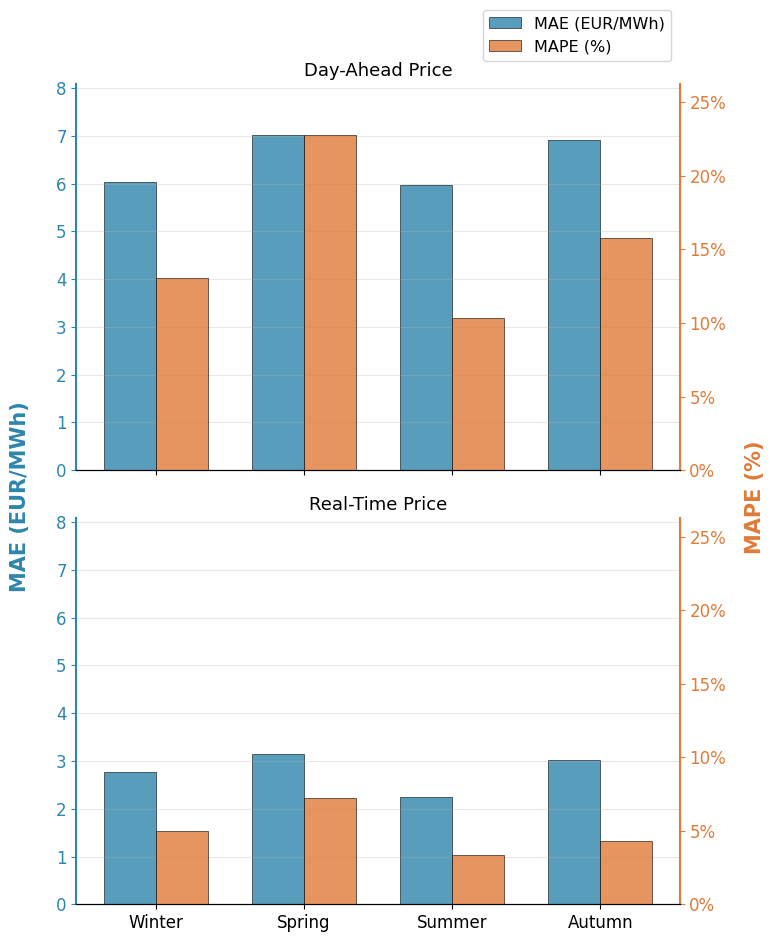

In [104]:
plot_seasonal_comparison(da_season_results, 
                         rt_season_results, 
                         color_mae='#2E86AB',
                         color_mape='#E07B39',
                         legend_loc='upper left',
                         legend_bbox=(0.62,1.05), 
                         save_path='../plots/seasonal_error_v1.png',
                        )

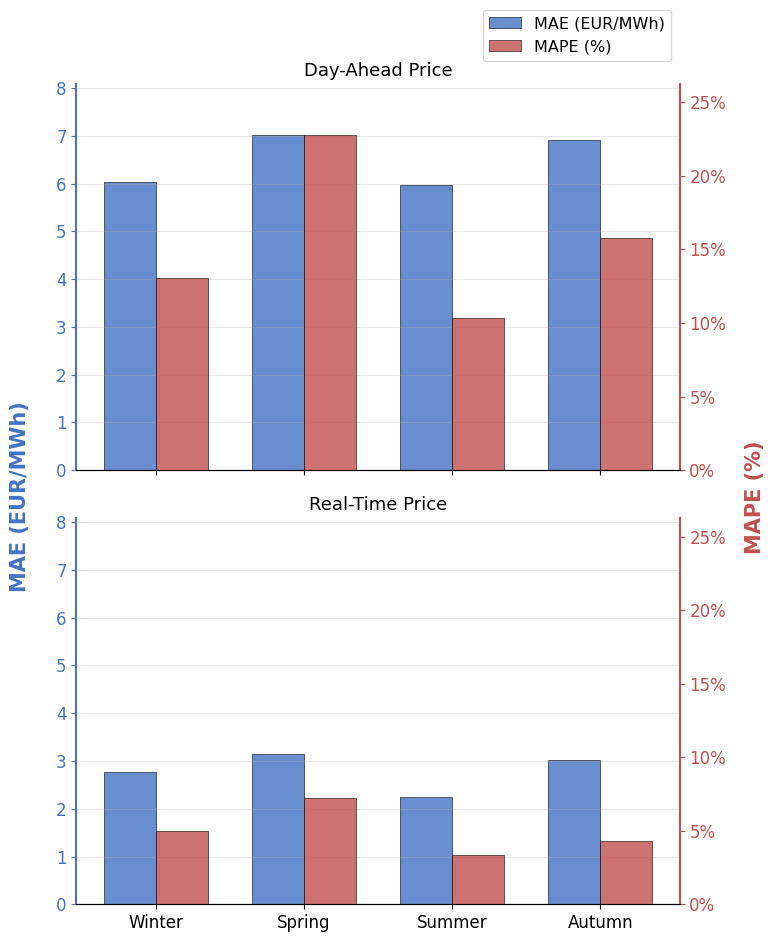

In [105]:
plot_seasonal_comparison(da_season_results, 
                         rt_season_results, 
                         color_mae='#4472C4', 
                         color_mape='#C0504D',
                         legend_loc='upper left',
                         legend_bbox=(0.62,1.05), 
                         save_path='../plots/seasonal_error_v2.png',
)

In [ ]:
plot_seasonal_comparison(da_season_results, 
                         rt_season_results, 
                         color_mae='#5C6BC0', 
                         color_mape='#E76F79',
                         legend_loc='upper left',
                         legend_bbox=(0.62,1.05),
                         save_path='../plots/seasonal_error_v3.png',
                        )

In [ ]:
plot_seasonal_comparison(da_season_results, 
                         rt_season_results, 
                         color_mae='#3A7EBF', 
                         color_mape='#3A7D44',
                         legend_loc='upper left',
                         legend_bbox=(0.62,1.05), 
                         save_path='../plots/seasonal_error_v4.png',
                        )

In [43]:
import json
import numpy as np

def save_history(history, path):
    with open(path, 'w') as f:
        json.dump(history, f)

def save_results(results, path):
    serializable = {
        k: v.tolist() if isinstance(v, np.ndarray) else v
        for k, v in results.items()
    }
    with open(path, 'w') as f:
        json.dump(serializable, f)

def load_results(path):
    with open(path) as f:
        data = json.load(f)
    # convert lists back to arrays where needed
    array_keys = {'preds', 'actuals', 'mae_per_horizon'}
    return {
        k: np.array(v) if k in array_keys else v
        for k, v in data.items()
    }

### Save results `json` 

In [44]:
save_results(results, output_dir / 'da_transformer_results.json')

save_history(history, output_dir / 'da_transformer_history.json')

### Sample day Actual vs Pred plots 

#### read json files 

In [45]:
da_transformer = load_results(output_dir / 'da_transformer_results.json')
rt_transformer = load_results(output_dir / 'rt_transformer_results.json')
da_cnn    = load_results(output_dir / 'da_cnn_results.json')
rt_cnn    = load_results(output_dir / 'rt_cnn_results.json')

#### aligning this with the results from the sequential pipeline 

In [46]:
offset = 144

rt_transformer_aligned = {
    'preds'   : rt_transformer['preds'][offset:],
    'actuals' : rt_transformer['actuals'][offset:],
}

rt_cnn_aligned = {
    'preds'   : rt_cnn['preds'][offset:],
    'actuals' : rt_cnn['actuals'][offset:],
}

In [47]:
da_offset = 5

da_transformer_aligned = {
    'preds'   : da_transformer['preds'][da_offset:],
    'actuals' : da_transformer['actuals'][da_offset:],
}

da_cnn_aligned = {
    'preds'   : da_cnn['preds'][da_offset:],
    'actuals' : da_cnn['actuals'][da_offset:],
}

### read files - non-sequential 

#### TRANSFORMER 

In [48]:
import numpy as np

results_dir = Path('../CNN-LSTM/test_results_transformer')

# Day-Ahead
da_transformer_preds   = np.load(results_dir / 'price_day_ahead_preds.npy')
da_transformer_actuals = np.load(results_dir / 'price_day_ahead_actuals.npy')

# Real-Time
rt_transformer_preds   = np.load(results_dir / 'price_actual_preds.npy')
rt_transformer_actuals = np.load(results_dir / 'price_actual_actuals.npy')

print(da_transformer_preds.shape, da_transformer_actuals.shape)
print(rt_transformer_preds.shape, rt_transformer_actuals.shape)

(8568, 24) (8568, 24)
(8591, 1) (8591, 1)


#### CNN LSTM 

In [49]:
import numpy as np

results_dir = Path('../CNN-LSTM/test_results_cnnlstm')

# Day-Ahead
da_cnn_preds   = np.load(results_dir / 'price_day_ahead_preds.npy')
da_cnn_actuals = np.load(results_dir / 'price_day_ahead_actuals.npy')

# Real-Time
rt_cnn_preds   = np.load(results_dir / 'price_actual_preds.npy')
rt_cnn_actuals = np.load(results_dir / 'price_actual_actuals.npy')

print(da_cnn_preds.shape, da_cnn_actuals.shape)
print(rt_cnn_preds.shape, rt_cnn_actuals.shape)

(8568, 24) (8568, 24)
(8591, 1) (8591, 1)


In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

rt_transformer_results_SEQ = {
    'preds'    : rt_transformer_preds,
    'actuals'  : rt_transformer_actuals,
}

rt_cnn_results_SEQ = {
    'preds'    : rt_cnn_preds,
    'actuals'  : rt_cnn_actuals,
}


da_transformer_results_SEQ = {
    'preds'    : da_transformer_preds,
    'actuals'  : da_transformer_actuals,
}

da_cnn_results_SEQ = {
    'preds'    : da_cnn_preds,
    'actuals'  : da_cnn_actuals,
}

In [51]:
def plot_model_comparison(
    results_a,
    results_b,
    results_c=None,
    results_d=None,
    label_a='Transformer',
    label_b='CNN+BiLSTM',
    label_c='Transformer (Seq)',
    label_d='CNN+BiLSTM (Seq)',
    market='DA',
    idx=None,
    plot_days=7,
    xtick_freq=None,
    figsize=(12, 4),
    xlabel_size=12,
    ylabel_size=13,
    tick_size=11,
    legend_loc='upper right',
    legend_bbox=None,
    legend_fontsize=11,
    save_path=None,
    dpi=300,
):
    all_results = [results_a, results_b]
    all_labels  = [label_a,   label_b]
    if results_c is not None:
        all_results.append(results_c)
        all_labels.append(label_c)
    if results_d is not None:
        all_results.append(results_d)
        all_labels.append(label_d)

    n_models     = len(all_results)
    nrows, ncols = (2, 2) if n_models > 2 else (1, 2)
    fig_h        = figsize[1] * 2 if nrows == 2 else figsize[1]

    fig, axes_2d = plt.subplots(nrows, ncols, figsize=(figsize[0], fig_h), sharey=True)
    axes         = axes_2d.ravel() if nrows == 2 else axes_2d

    horizon_a  = results_a['actuals'].shape[1]
    multi_step = horizon_a > 1

    ylabel_map = {
        'DA': 'Day-ahead Price (EUR/MWh)',
        'RT': 'Real-time Price (EUR/MWh)',
    }
    ylabel_str = ylabel_map.get(market, f'{market} Price (EUR/MWh)')

    if multi_step:
        n_windows = results_a['preds'].shape[0]
        if idx is None:
            idx = np.random.randint(0, n_windows)

        freq = xtick_freq if xtick_freq is not None else 4

        for ax, results, label in zip(axes, all_results, all_labels):
            horizon = results['actuals'].shape[1]
            actuals = results['actuals'][idx]
            preds   = results['preds'][idx]
            hours   = range(horizon)

            ax.plot(hours, actuals, marker='o', markersize=4, linewidth=1.5,
                    label='Actual',    color='steelblue')
            ax.plot(hours, preds,   marker='x', markersize=4, linewidth=1.5,
                    label='Predicted', color='darkorange', linestyle='--')

            ax.set_title(f'{label}', fontsize=12)
            ax.set_xticks(range(0, horizon, freq))

        xlabel_str = 'Hour ahead'

    else:
        n_hours = plot_days * 24
        if idx is None:
            max_start = results_a['preds'].shape[0] - n_hours
            idx = np.random.randint(0, max(1, max_start))
        n = min(n_hours, results_a['preds'].shape[0] - idx)

        freq = xtick_freq if xtick_freq is not None else 12

        for ax, results, label in zip(axes, all_results, all_labels):
            actuals = results['actuals'][idx: idx + n, 0]
            preds   = results['preds'][idx: idx + n, 0]
            hours   = range(n)

            ax.plot(hours, actuals, linewidth=1.2,
                    label='Actual',    color='steelblue')
            ax.plot(hours, preds,   linewidth=1.2,
                    label='Predicted', color='darkorange', linestyle='--')

            ax.set_title(f'{label}', fontsize=12)
            ax.set_xticks(np.arange(0, n + 1, freq))

        xlabel_str = 'Hour'

    for ax in axes:
        ax.tick_params(labelsize=tick_size)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()

    ax_left  = axes[0].get_position()
    ax_right = axes[ncols - 1].get_position()
    center_x = (ax_left.x0 + ax_right.x1) / 2
    fig.text(center_x, -0.02, xlabel_str, fontsize=xlabel_size,
             fontweight='bold', ha='center', va='bottom')

    ax_top    = axes[0].get_position()
    ax_bottom = axes[(nrows - 1) * ncols].get_position()
    center_y  = (ax_top.y1 + ax_bottom.y0) / 2
    fig.text(-0.02, center_y, ylabel_str, fontsize=ylabel_size,
             fontweight='bold', ha='left', va='center', rotation='vertical')

    handles, labels = axes[0].get_legend_handles_labels()
    legend_kwargs   = dict(fontsize=legend_fontsize, loc=legend_loc)
    if legend_bbox is not None:
        legend_kwargs['bbox_to_anchor'] = legend_bbox
    fig.legend(handles, labels, **legend_kwargs)

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()

In [52]:
## define index to plot 

index = 0

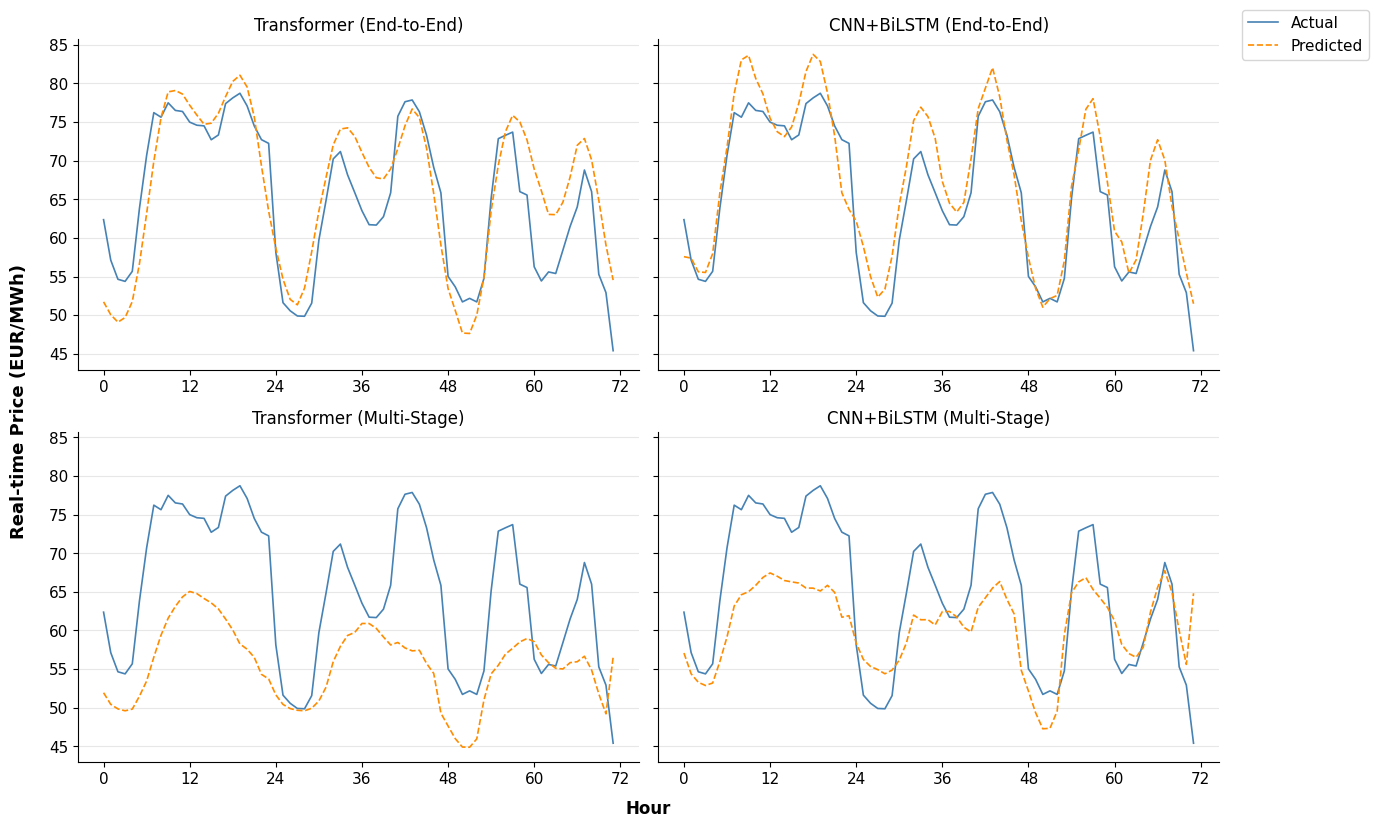

In [53]:
plot_model_comparison(
    results_a=rt_transformer_aligned,
    results_b=rt_cnn_aligned,
    results_c=rt_transformer_results_SEQ,
    results_d=rt_cnn_results_SEQ,
    label_a='Transformer (End-to-End)',
    label_b='CNN+BiLSTM (End-to-End)',
    label_c='Transformer (Multi-Stage)',
    label_d='CNN+BiLSTM (Multi-Stage)',
    market='RT',
    idx=index,
    plot_days=3,
    legend_loc='upper left',
    legend_bbox=(1, 1),
    
    figsize=(12, 4),
    # save_path='../plots/real_time_price_comparison.png',
)

### RT 1-day 

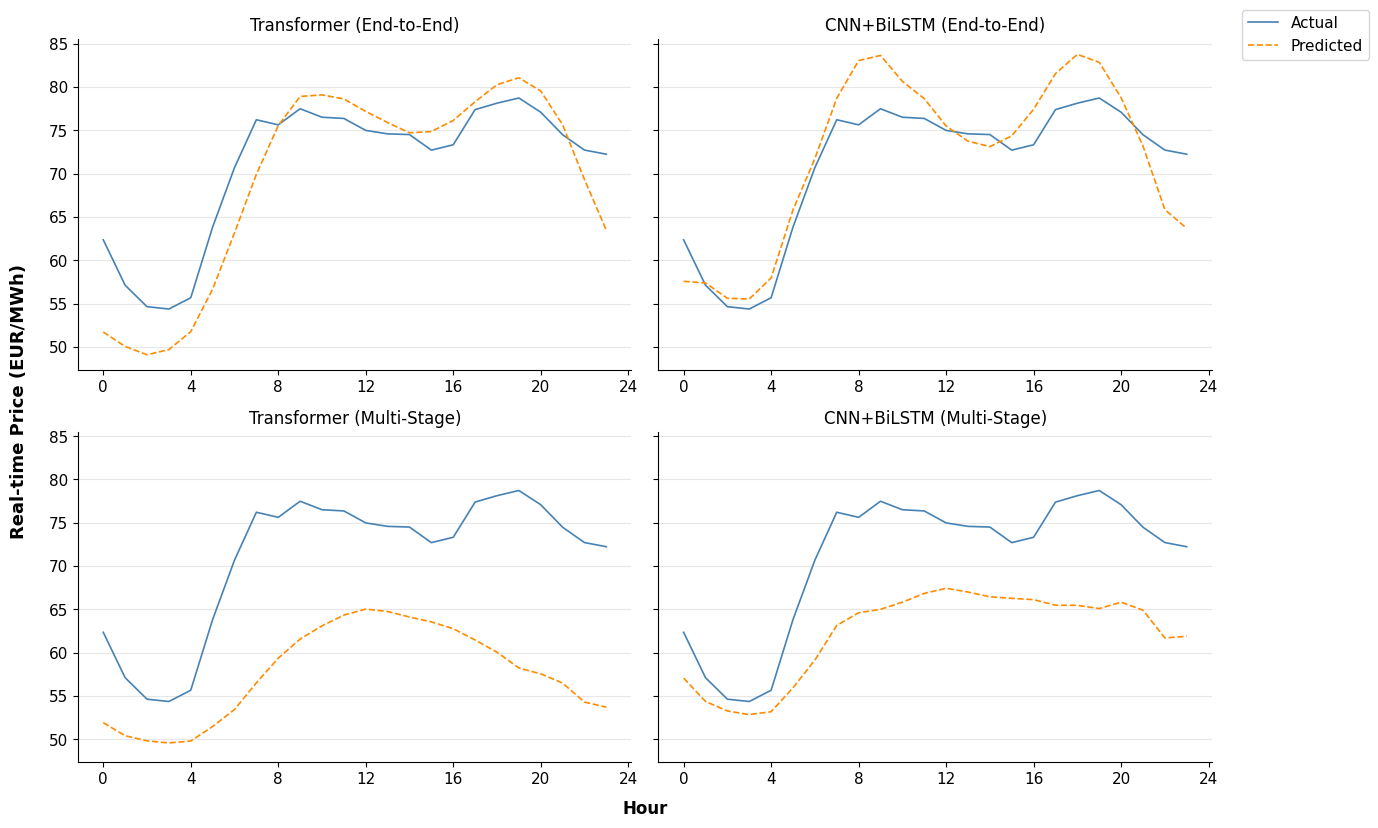

In [54]:
plot_model_comparison(
    results_a=rt_transformer_aligned,
    results_b=rt_cnn_aligned,
    results_c=rt_transformer_results_SEQ,
    results_d=rt_cnn_results_SEQ,
    label_a='Transformer (End-to-End)',
    label_b='CNN+BiLSTM (End-to-End)',
    label_c='Transformer (Multi-Stage)',
    label_d='CNN+BiLSTM (Multi-Stage)',
    market='RT',
    idx=index,
    plot_days=1,
    legend_loc='upper left',
    legend_bbox=(1, 1),
    xtick_freq=4,
    
    figsize=(12, 4),
    # save_path='../plots/real_time_price_comparison_1_day.png',
)

### RT 7-day 

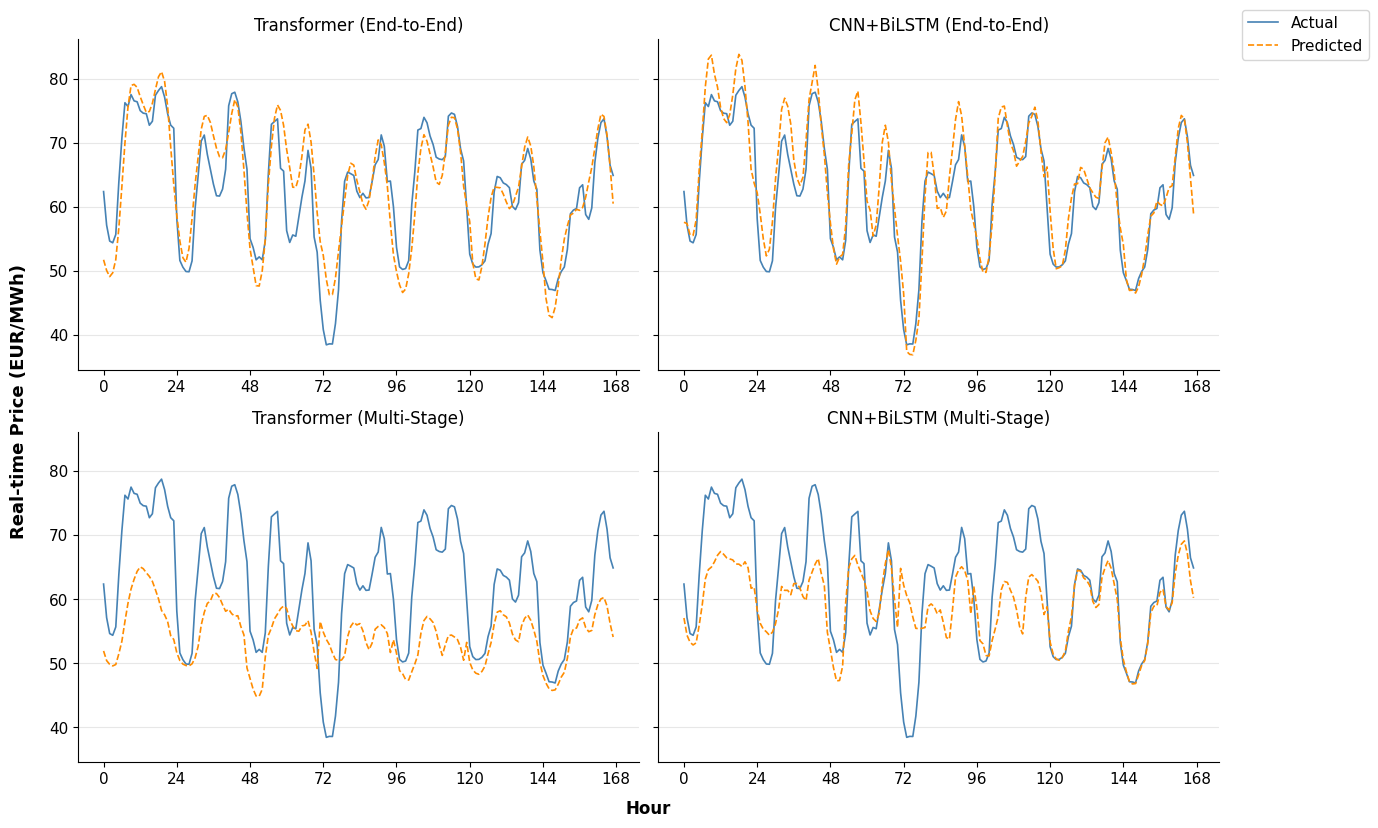

In [55]:
plot_model_comparison(
    results_a=rt_transformer_aligned,
    results_b=rt_cnn_aligned,
    results_c=rt_transformer_results_SEQ,
    results_d=rt_cnn_results_SEQ,
    label_a='Transformer (End-to-End)',
    label_b='CNN+BiLSTM (End-to-End)',
    label_c='Transformer (Multi-Stage)',
    label_d='CNN+BiLSTM (Multi-Stage)',
    market='RT',
    idx=index,
    plot_days=7,
    legend_loc='upper left',
    legend_bbox=(1, 1),
     xtick_freq=24,
    
    figsize=(12, 4),
    save_path='../plots/real_time_price_comparison_7_days.png',
)

### Day-ahead plots 

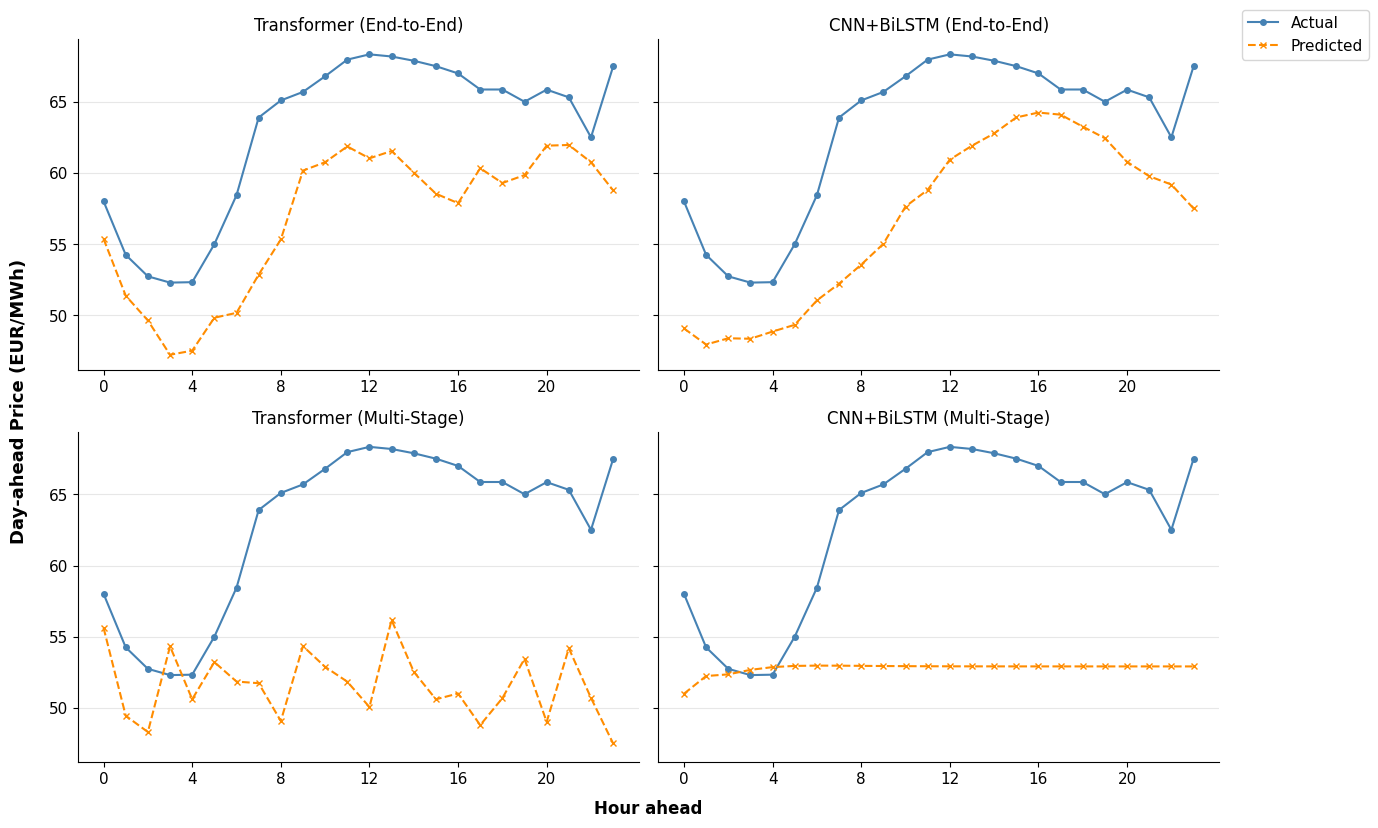

In [56]:
plot_model_comparison(
    results_a = da_transformer_aligned,
    results_b = da_cnn_aligned,
    results_c = da_transformer_results_SEQ,
    results_d = da_cnn_results_SEQ,
    label_a = 'Transformer (End-to-End)',
    label_b = 'CNN+BiLSTM (End-to-End)',
    label_c = 'Transformer (Multi-Stage)',
    label_d = 'CNN+BiLSTM (Multi-Stage)',
    market='DA',
    idx=index,
    plot_days=3,
    legend_loc='upper left',
    legend_bbox=(1, 1),
    
    figsize=(12, 4),
        save_path='../plots/day_ahead_price_comparison.png',
)

In [57]:
## sequential one has shift/stride of 1 instead of 24 so just using the 0th index 

### Train/Val Loss Curves for Direct Transformer (DA) & Direct CNN (RT) 

In [58]:
def load_history(path):
    with open(path) as f:
        return json.load(f)

In [59]:
da_transformer_history = load_history(output_dir / 'da_transformer_history.json')
rt_cnn_history         = load_history(output_dir / 'rt_cnn_history.json')

In [60]:
def plot_training_history(
    history_a,
    history_b,
    label_a='Transformer (DA)',
    label_b='CNN+BiLSTM (RT)',
    figsize=(12, 4),
    xlabel_size=12,
    ylabel_size=13,
    tick_size=11,
    legend_loc='upper right',
    legend_fontsize=10,
    save_path=None,
    dpi=300,
):
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    for ax, history, label in zip(axes, [history_a, history_b], [label_a, label_b]):
        epochs = range(1, len(history['train_loss']) + 1)
        ax.plot(epochs, history['train_loss'], label='Train', color='steelblue',  linewidth=1.5)
        ax.plot(epochs, history['val_loss'],   label='Val',   color='darkorange', linewidth=1.5, linestyle='--')
        ax.set_title(label, fontsize=12, fontweight='bold')
        ax.tick_params(labelsize=tick_size)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', alpha=0.3)
        ax.legend(fontsize=legend_fontsize, loc=legend_loc)

    axes[0].set_ylabel('Loss (scaled)', fontsize=ylabel_size, fontweight='bold', labelpad=10)

    plt.tight_layout()

    ax_left  = axes[0].get_position()
    ax_right = axes[1].get_position()
    center_x = (ax_left.x0 + ax_right.x1) / 2
    fig.text(center_x, 0.01, 'Epoch', fontsize=xlabel_size,
             fontweight='bold', ha='center', va='bottom')

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()

In [61]:
def plot_training_history(
    history_a,
    history_b,
    label_a='Transformer (DA)',
    label_b='CNN+BiLSTM (RT)',
    figsize=(8, 8),
    xlabel_size=12,
    ylabel_size=13,
    tick_size=11,
    legend_loc='upper left',
    legend_bbox=(1, 1),
    legend_fontsize=11,
    save_path=None,
    dpi=300,
):
    fig, axes = plt.subplots(2, 1, figsize=figsize)

    for ax, history, label in zip(axes, [history_a, history_b], [label_a, label_b]):
        epochs = range(1, len(history['train_loss']) + 1)
        ax.plot(epochs, history['train_loss'], label='Training Loss', color='steelblue',  linewidth=1.5)
        ax.plot(epochs, history['val_loss'],   label='Validation Loss',   color='darkorange', linewidth=1.5, linestyle='--')
        ax.set_title(label, fontsize=12, fontweight='bold')
        ax.tick_params(labelsize=tick_size)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', alpha=0.3)

    axes[-1].set_xlabel('Epoch', fontsize=xlabel_size, fontweight='bold')

    plt.tight_layout()

    # centered ylabel over both panels
    ax_top    = axes[0].get_position()
    ax_bottom = axes[1].get_position()
    center_y  = (ax_top.y1 + ax_bottom.y0) / 2
    fig.text(-0.02, center_y, 'Loss', fontsize=ylabel_size,
             fontweight='bold', ha='left', va='center', rotation='vertical')

    # single fig-level legend
    handles, labels = axes[0].get_legend_handles_labels()
    legend_kwargs   = dict(fontsize=legend_fontsize, loc=legend_loc)
    if legend_bbox is not None:
        legend_kwargs['bbox_to_anchor'] = legend_bbox
    fig.legend(handles, labels, **legend_kwargs)

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()

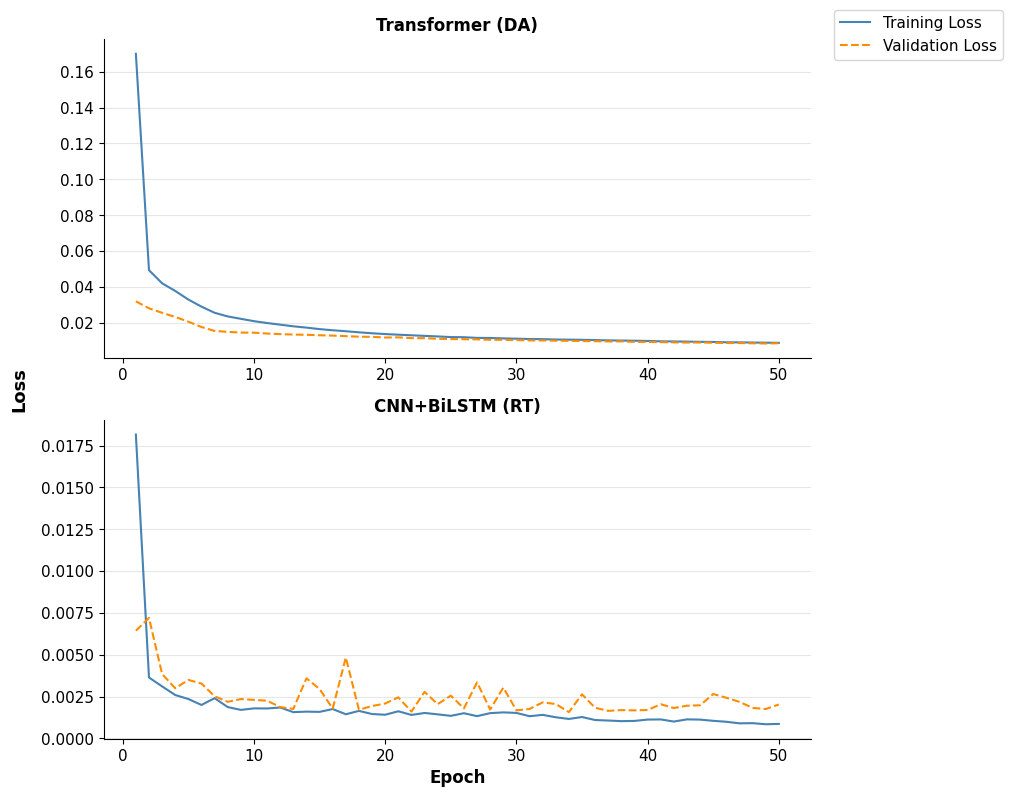

In [62]:
plot_training_history(da_transformer_history, rt_cnn_history)